# Predictive Models — 2024 US Presidential Election

**Goal:** Forecast the daily Polymarket Trump win-probability 1 day ahead.

**Target:** `polymarket_trump_prob` — the Polymarket market price scraped just after midnight,
representing the market consensus at end-of-day.

**Pipeline:**
1. Feature engineering & cleaning (basetable.ipynb)
2. Walk-forward cross-validation splits (Functions/data_splits.py)
3. Hyperparameter tuning via validation folds
4. Model comparison + final test set evaluation

**Models:** AR(1) Baseline · Ridge · Lasso · ElasticNet · Random Forest · XGBoost

## 1. Setup

Standard imports + house style. `apply_style()` sets the dark theme and colour palette
globally for all matplotlib figures in this notebook.

In [1]:
import sys, os, warnings, itertools
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../Functions'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping (pip install xgboost)")

from data_splits import get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage
from Descriptive.house_style import (
    apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, REPUBLICAN, DEMOCRAT, ACCENT,
    NEUTRAL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR, PALETTE
)
apply_style()
print("Setup complete.")

Setup complete.


## 2. Data & Feature Groups

We drop columns with **> 30% missing values** — imputing more than 30% of a column
introduces too much noise and the imputed values are no longer trustworthy.

Three feature sets are defined so we can test whether adding social/news data
actually improves over a simple poll+lag baseline:

| Feature set | Contents | Purpose |
|---|---|---|
| `FEAT_AR` | lag1 only | Hard floor — minimum achievable error |
| `FEAT_POLLS` | lag1 + polls | Realistic strong baseline |
| `FEAT_ALL` | lag1 + all remaining features | Full model |
|  | lag1 + LSA components only | Pure text signal |
|  | lag1 + all features + LSA | Everything |

In [2]:
df = pd.read_csv('../Data/3_Gold/basetable.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

TARGET = 'polymarket_trump_prob'

# Drop columns with > 30% NaN — too sparse to impute reliably
nan_pct   = df.isna().mean()
DROP_SPARSE = list(nan_pct[nan_pct > 0.30].index)
EXCL        = ['date', TARGET]
print(f"Dropping {len(DROP_SPARSE)} sparse columns: {DROP_SPARSE}")

ALL_FEAT = [c for c in df.columns if c not in DROP_SPARSE + EXCL]

FEAT_AR    = ['polymarket_trump_prob_lag1']
FEAT_POLLS = FEAT_AR + ['poll_trump_avg', 'poll_harris_avg',
                         'poll_margin', 'poll_trump_7d_avg']
FEAT_ALL   = ALL_FEAT   # lag1 already in ALL_FEAT (not in EXCL)

print(f"\nFeature set sizes:  AR={len(FEAT_AR)}  |  Polls={len(FEAT_POLLS)}  |  All={len(FEAT_ALL)}")
print(f"Rows: {len(df)}  |  {df['date'].min().date()} → {df['date'].max().date()}")
# ── Text (TF-IDF/LSA) features from text_features.ipynb ─────────────────────
# Run Predictive/text_features.ipynb first to generate this file.
try:
    text_feat = pd.read_csv('../Data/3_Gold/text_features.csv', parse_dates=['date'])
    df = df.merge(text_feat, on='date', how='left')
    TEXT_COLS = [c for c in text_feat.columns if c != 'date']
    FEAT_TEXT = ['polymarket_trump_prob_lag1'] + TEXT_COLS
    FEAT_ALL_TEXT = FEAT_ALL + TEXT_COLS
    print(f"Text features loaded: {len(TEXT_COLS)} LSA components")
    HAS_TEXT = True
except FileNotFoundError:
    print("text_features.csv not found — run text_features.ipynb first")
    FEAT_TEXT = FEAT_ALL
    FEAT_ALL_TEXT = FEAT_ALL
    HAS_TEXT = False
# ── Raw text features (aggregated per day in text_features.ipynb) ─────────────
# TF-IDF is NOT pre-computed here — it is fitted per fold inside the pipeline
# to prevent leakage of IDF weights from validation/test into training data.
try:
    text_raw = pd.read_csv('../Data/3_Gold/text_raw_daily.csv', parse_dates=['date'])
    for col in ['bsky_text', 'reddit_text', 'news_text']:
        text_raw[col] = text_raw[col].fillna('')
    df = df.merge(text_raw[['date','bsky_text','reddit_text','news_text']],
                  on='date', how='left')
    for col in ['bsky_text','reddit_text','news_text']:
        df[col] = df[col].fillna('')
    TEXT_COLS = ['bsky_text', 'reddit_text', 'news_text']
    HAS_TEXT  = True
    print(f"Raw text loaded: {len(TEXT_COLS)} text columns merged")
except FileNotFoundError:
    print("text_raw_daily.csv not found — run text_features.ipynb first")
    TEXT_COLS = []
    HAS_TEXT  = False

Dropping 8 sparse columns: ['sp500_vol_30d', 'sp500_dist_from_high_30d', 'sp500_dist_from_low_30d', 'sp500_zscore_30d', 'sp500_sma_cross_7_30', 'oil_dist_from_high_30d', 'oil_zscore_30d', 'macro_real_gdp']

Feature set sizes:  AR=1  |  Polls=5  |  All=87
Rows: 124  |  2024-07-05 → 2024-11-05
text_features.csv not found — run text_features.ipynb first


Raw text loaded: 3 text columns merged


## 3. Walk-forward CV Splits

**Why walk-forward and not standard k-fold?**
Standard k-fold randomly shuffles the data, so a validation fold can contain dates
that are *earlier* than some training dates — the model "sees the future" during training.
Walk-forward always trains on the past and validates on the next period, exactly
replicating real-world deployment.

**Why an expanding (not sliding) window?**
Early-campaign data (Biden dropout, first assassination attempt) stays informative
throughout the election campaign. Discarding it in a sliding window would throw away
signal.

**Why gap=1?**
Features include rolling averages and lags. Without a gap, the first validation day's
rolling feature would still overlap with training rows, causing a minor form of leakage.
Gap=1 mirrors the actual task: observe day *t−1*, predict day *t*.

**Test set:** the final 14 days are **never touched** during tuning or model selection.

In [3]:
TEST_DAYS = 14
N_SPLITS  = 3
GAP       = 1

tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)
folds = get_cv_folds(df, n_splits=N_SPLITS, gap=GAP, test_days=TEST_DAYS)

print(f"Train/val : {len(tv_idx)} rows  "
      f"({df['date'].iloc[tv_idx[0]].date()} → {df['date'].iloc[tv_idx[-1]].date()})")
print(f"Test      : {len(test_idx)} rows  "
      f"({df['date'].iloc[test_idx[0]].date()} → {df['date'].iloc[test_idx[-1]].date()})")
print()
print_fold_summary(df, folds)
print()
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df, gap=GAP)
    print(f"  Fold {i} leakage check: OK")

Train/val : 110 rows  (2024-07-05 → 2024-10-22)
Test      : 14 rows  (2024-10-23 → 2024-11-05)

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-08-01       28    2024-08-03    2024-08-29      27
   2    2024-07-05    2024-08-28       55    2024-08-30    2024-09-25      27
   3    2024-07-05    2024-09-24       82    2024-09-26    2024-10-22      27

  Fold 1 leakage check: OK
  Fold 2 leakage check: OK
  Fold 3 leakage check: OK


## 4. Preprocessing & Metrics

**Preprocessing pipeline (per fold, fit only on train):**
1. `SimpleImputer(median)` — replaces remaining NaN with the training median.
   Using the *training* median prevents leakage from the validation/test set.
2. `StandardScaler` — centres and scales each feature to mean=0, std=1.
   Required for Ridge/Lasso/ElasticNet (penalised methods assume equal feature scales).
   Tree models are scale-invariant but scaling doesn't hurt them.

**Metrics:**
| Metric | Formula | Interpretation |
|---|---|---|
| MAE | mean\|y − ŷ\| | Average error in probability points — primary metric |
| RMSE | √mean(y − ŷ)² | Penalises large errors more than MAE |
| R² | 1 − SS_res/SS_tot | Fraction of variance explained (1 = perfect, 0 = mean pred) |
| DirAcc | % days correct direction | Did we predict correctly whether prob went up or down? |

In [4]:
def make_pipeline(model):
    """
    Median imputation → StandardScaler → model.
    The pipeline is cloned and refitted for each fold/param combination
    so no information leaks between train and val.
    """
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

def score_fold(pipeline, feat_cols, train_idx, val_idx):
    """Fit pipeline on train, return MAE on val."""
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[train_idx], df[TARGET].iloc[train_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[val_idx])
    return mean_absolute_error(df[TARGET].iloc[val_idx], y_pred)

def directional_accuracy(y_true, y_pred, y_lag):
    """Fraction of days where predicted direction of change matches actual."""
    actual_dir    = np.sign(np.array(y_true) - np.array(y_lag))
    predicted_dir = np.sign(np.array(y_pred) - np.array(y_lag))
    mask = actual_dir != 0
    return (actual_dir[mask] == predicted_dir[mask]).mean() if mask.sum() > 0 else np.nan

def eval_pipeline(pipeline, feat_cols, train_idx, val_idx):
    """Full metric set for one fold."""
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[train_idx], df[TARGET].iloc[train_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[val_idx])
    y_true = df[TARGET].iloc[val_idx]
    lag    = df['polymarket_trump_prob_lag1'].iloc[val_idx]
    return {
        'MAE':    mean_absolute_error(y_true, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':     r2_score(y_true, y_pred),
        'DirAcc': directional_accuracy(y_true, y_pred, lag),
        'y_pred': y_pred,
        'y_true': y_true.values,
        'dates':  df['date'].iloc[val_idx].values,
    }

print("Helper functions defined.")

# ── Text-aware pipeline (per-fold TF-IDF via ColumnTransformer) ──────────────
#
# Fit/transform schema (strictly respected):
#   fit   on X_train  → learns vocabulary + IDF weights from training days only
#   transform X_train → TF-IDF + SVD → dense LSA matrix
#   transform X_val   → same vectorizer applied to val days (no fitting)
#
# ColumnTransformer automatically applies this correctly when the pipeline
# is clone()'d and refit on each fold.

from sklearn.compose import ColumnTransformer

def make_text_pipeline(model, numeric_cols, text_cols=None,
                        n_components=10, max_features=500):
    """
    Pipeline that handles numeric features AND raw text columns.

    Numeric branch : SimpleImputer(median) → StandardScaler
    Text branch    : TfidfVectorizer → TruncatedSVD (LSA)
                     One branch per text column, all fitted on training data only.

    Parameters
    ----------
    model        : sklearn estimator
    numeric_cols : list of numeric feature column names
    text_cols    : list of text column names (default: all three sources)
    n_components : LSA components per text source
    max_features : max TF-IDF vocabulary size per source
    """
    if text_cols is None:
        text_cols = ['bsky_text', 'reddit_text', 'news_text']

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

    text_transformers = []
    for col in text_cols:
        text_pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features,
                min_df=2,           # must appear on ≥2 training days
                max_df=0.95,        # ignore terms in >95% of training days
                ngram_range=(1, 2), # unigrams + bigrams
                sublinear_tf=True,  # log(1+tf) — dampens high-freq terms
                stop_words='english',
            )),
            ('svd', TruncatedSVD(n_components=n_components, random_state=42)),
        ])
        text_transformers.append((f'text_{col}', text_pipe, col))

    ct = ColumnTransformer(
        transformers=[('numeric', numeric_transformer, numeric_cols)]
        + text_transformers,
        remainder='drop',
    )

    return Pipeline([('features', ct), ('model', model)])


Helper functions defined.


## 5. Hyperparameter Tuning

**Strategy: manual walk-forward grid search**

We do NOT use sklearn's `GridSearchCV` because it applies k-fold CV internally,
which would shuffle the time series and violate temporal order.
Instead we loop over every hyperparameter combination and compute the **mean MAE
across the same 3 walk-forward folds** used for model selection.

The hyperparameter combination with the lowest mean MAE across the 3 folds
is selected. This is identical in spirit to GridSearchCV but respects the
arrow of time.

**Important:** hyperparameter selection is based solely on the validation folds.
The test set is never touched during this process.

In [5]:
# ── Parameter grids ──────────────────────────────────────────────────────────
#
# Walk-forward manual grid search:
#   For each hyperparameter combination we run 3 CV folds and record mean MAE.
#   We pick the combo with the lowest mean MAE across folds.
#   sklearn GridSearchCV is NOT used here because it shuffles data internally
#   and would break the time ordering of our walk-forward validation.
#
# Text models (Lasso + Text, XGBoost + Text) use make_text_pipeline() which
# wraps a ColumnTransformer.  Because clone() + fit() is called per fold, the
# TF-IDF vectorizer learns its vocabulary and IDF weights ONLY from the
# training rows of each fold — validation/test rows are never seen at fit time.
#
# Grid sizes are intentionally small to keep total runtime manageable:
#   Lasso         7 alphas  × 3 folds =  21 fits
#   ElasticNet   20 combos  × 3 folds =  60 fits
#   RF           18 combos  × 3 folds =  54 fits
#   XGBoost      12 combos  × 3 folds =  36 fits
#   Lasso+Text    5 alphas  × 3 folds =  15 fits  (TF-IDF per fold)
#   XGBoost+Text  6 combos  × 3 folds =  18 fits  (TF-IDF per fold)

PARAM_GRIDS = {
    'AR(1) Baseline': {'model__alpha': [1e-9], 'feats': [FEAT_AR]},
    'Ridge':     {'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000], 'feats': [FEAT_ALL]},
    'Lasso':     {'model__alpha': [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05, 0.1], 'feats': [FEAT_ALL]},
    'ElasticNet':{'model__alpha': [1e-4, 0.001, 0.01, 0.1],
                  'model__l1_ratio': [0.1, 0.5, 0.9, 0.99], 'feats': [FEAT_ALL]},
    'Random Forest': {'model__max_depth': [2, 3, 4],
                      'model__min_samples_leaf': [3, 5, 8],
                      'model__n_estimators': [100, 200], 'feats': [FEAT_ALL]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost'] = {
        'model__n_estimators': [50, 100, 200], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05, 0.1],
        'feats': [FEAT_ALL]}
if HAS_TEXT:
    # Smaller grids for text models — TF-IDF+SVD per fold adds overhead
    PARAM_GRIDS['Lasso + Text'] = {
        'model__alpha': [1e-4, 0.001, 0.01, 0.05, 0.1],
        'feats': [FEAT_ALL], 'use_text': [True]}
    if HAS_XGB:
        PARAM_GRIDS['XGBoost + Text'] = {
            'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
            'model__learning_rate': [0.05, 0.1],
            'feats': [FEAT_ALL], 'use_text': [True]}

BASE_ESTIMATORS = {
    'AR(1) Baseline': Ridge(),
    'Ridge':          Ridge(),
    'Lasso':          Lasso(max_iter=10000),
    'ElasticNet':     ElasticNet(max_iter=10000),
    'Random Forest':  RandomForestRegressor(random_state=42, n_jobs=-1),
    'Lasso + Text':   Lasso(max_iter=10000),
}
if HAS_XGB:
    BASE_ESTIMATORS['XGBoost']        = XGBRegressor(random_state=42, verbosity=0)
    BASE_ESTIMATORS['XGBoost + Text'] = XGBRegressor(random_state=42, verbosity=0)

# ── Tuning loop ────────────────────────────────────────────────────────────────
tuning_results = {}
TUNED_MODELS   = {}

for model_name, grid in PARAM_GRIDS.items():
    feat_cols = grid.get('feats', [FEAT_ALL])[0]
    use_text  = bool(grid.get('use_text', [False])[0] if isinstance(
                    grid.get('use_text', False), list) else grid.get('use_text', False))

    # Collect only the model__ hyperparameter keys
    param_keys = [k for k in grid if k.startswith('model__')]
    param_vals = [grid[k] for k in param_keys]

    # Build pipeline factory for this model
    def _make(estimator, feat_cols=feat_cols, use_text=use_text):
        if use_text:
            numeric_cols = [c for c in feat_cols if c not in TEXT_COLS]
            return make_text_pipeline(estimator, numeric_cols, TEXT_COLS)
        else:
            return make_pipeline(estimator)

    # Special case: AR(1) — no hyperparams to tune
    if model_name == 'AR(1) Baseline':
        pipe = make_pipeline(Ridge(alpha=1e-9))
        fold_maes = [score_fold(pipe, FEAT_AR, tr, va) for tr, va in folds]
        tuning_results[model_name] = {'best_params': {'alpha': 1e-9},
                                       'best_mae': np.mean(fold_maes),
                                       'best_feats': FEAT_AR, 'use_text': False,
                                       'all_results': []}
        TUNED_MODELS[model_name] = (pipe, FEAT_AR, False)
        print(f"AR(1) Baseline      fixed  |  CV MAE = {np.mean(fold_maes):.5f}")
        continue

    best_mae, best_params, best_pipe = np.inf, None, None
    all_combos = []

    for combo in itertools.product(*param_vals):
        params = dict(zip(param_keys, combo))
        estimator = clone(BASE_ESTIMATORS[model_name])
        estimator.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
        pipe = _make(estimator)

        # Mean MAE across 3 walk-forward validation folds.
        # For text models: ColumnTransformer fits TF-IDF ONLY on the training rows
        # of each fold, then transforms val rows with the frozen vectorizer.
        if use_text:
            fold_maes = [score_fold(pipe, feat_cols + TEXT_COLS, tr, va)
                         for tr, va in folds]
        else:
            fold_maes = [score_fold(pipe, feat_cols, tr, va) for tr, va in folds]

        mean_mae = np.mean(fold_maes)
        all_combos.append({'params': params, 'mean_mae': mean_mae})

        if mean_mae < best_mae:
            best_mae, best_params, best_pipe = mean_mae, params, pipe

    eff_feats = feat_cols + TEXT_COLS if use_text else feat_cols
    tuning_results[model_name] = {'best_params': best_params, 'best_mae': best_mae,
                                   'best_feats': eff_feats, 'use_text': use_text,
                                   'all_results': all_combos}
    TUNED_MODELS[model_name] = (best_pipe, eff_feats, use_text)
    n = len(all_combos)
    print(f"{model_name:<22} {n:>3} combos  |  best MAE={best_mae:.5f}  |  {best_params}")

print()
print("Tuning complete.")


AR(1) Baseline      fixed  |  CV MAE = 0.01258


Ridge                    7 combos  |  best MAE=0.03065  |  {'model__alpha': 1}


Lasso                    7 combos  |  best MAE=0.02145  |  {'model__alpha': 0.005}


ElasticNet              16 combos  |  best MAE=0.02154  |  {'model__alpha': 0.01, 'model__l1_ratio': 0.5}


Random Forest           18 combos  |  best MAE=0.04625  |  {'model__max_depth': 4, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}


XGBoost                 12 combos  |  best MAE=0.03913  |  {'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.1}


Lasso + Text             5 combos  |  best MAE=0.02500  |  {'model__alpha': 0.01}


XGBoost + Text           8 combos  |  best MAE=0.04711  |  {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Tuning complete.


## 6. Tuning Results

The table below shows the best hyperparameters selected by walk-forward CV,
and a visualisation of the MAE landscape for each model.

In [6]:
print(f"{'Model':<20} {'Best MAE':>10}  Best Parameters")
print("-" * 75)
for name, res in tuning_results.items():
    params_str = '  '.join(f"{k.replace('model__','')}={v}" for k, v in res['best_params'].items())
    print(f"{name:<20} {res['best_mae']:>10.5f}  {params_str}")

Model                  Best MAE  Best Parameters
---------------------------------------------------------------------------
AR(1) Baseline          0.01258  alpha=1e-09
Ridge                   0.03065  alpha=1
Lasso                   0.02145  alpha=0.005
ElasticNet              0.02154  alpha=0.01  l1_ratio=0.5
Random Forest           0.04625  max_depth=4  min_samples_leaf=3  n_estimators=100
XGBoost                 0.03913  n_estimators=100  max_depth=2  learning_rate=0.1
Lasso + Text            0.02500  alpha=0.01
XGBoost + Text          0.04711  n_estimators=100  max_depth=3  learning_rate=0.1


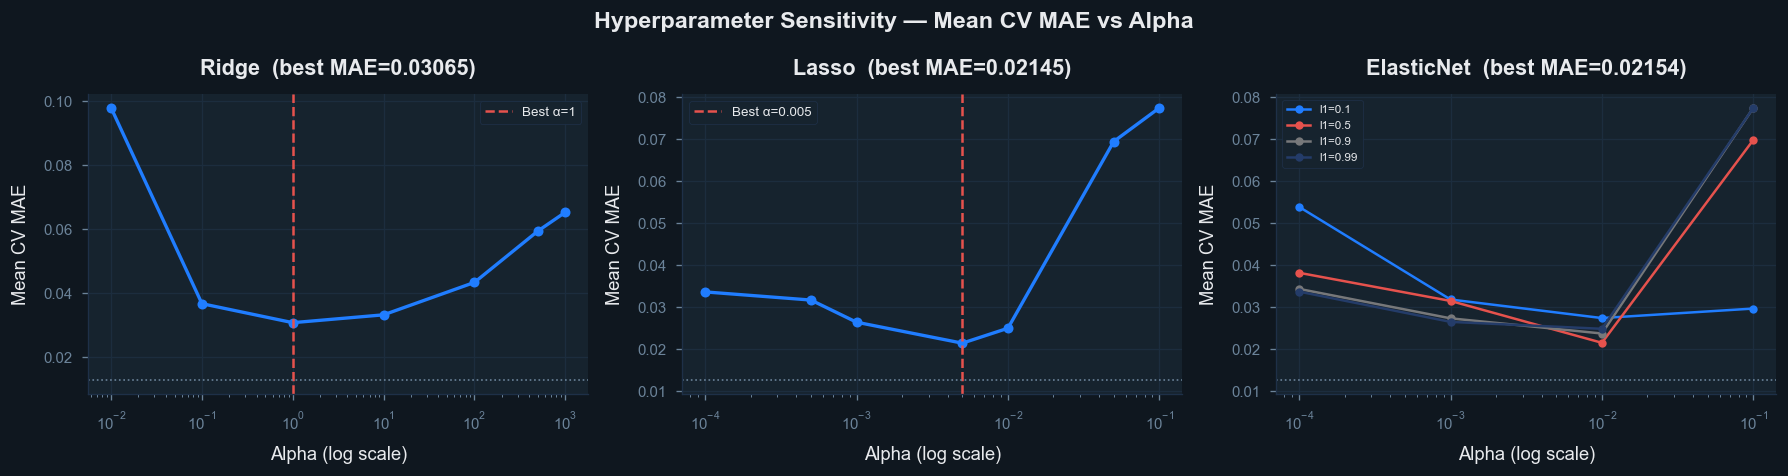

In [7]:
# ── Alpha sensitivity plots for penalised linear models ──────────────────────
linear_models = [m for m in ['Ridge', 'Lasso', 'ElasticNet']
                 if m in tuning_results and tuning_results[m]['all_results']]

fig, axes = plt.subplots(1, len(linear_models), figsize=(5 * len(linear_models), 4))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Hyperparameter Sensitivity — Mean CV MAE vs Alpha',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

if len(linear_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, linear_models):
    ax.set_facecolor(BG_PANEL)
    res = tuning_results[model_name]['all_results']

    if model_name == 'ElasticNet':
        # Group by l1_ratio, plot one line per l1_ratio
        combos_df = pd.DataFrame([{**r['params'], 'mae': r['mean_mae']} for r in res])
        for l1r, grp in combos_df.groupby('model__l1_ratio'):
            grp = grp.sort_values('model__alpha')
            ax.plot(grp['model__alpha'], grp['mae'], marker='o', ms=4,
                    label=f'l1={l1r}', lw=1.5)
        ax.set_xscale('log')
        ax.legend(fontsize=7, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
                  labelcolor=TEXT_PRIMARY)
    else:
        alphas  = [r['params']['model__alpha'] for r in res]
        maes    = [r['mean_mae'] for r in res]
        best_a  = tuning_results[model_name]['best_params']['model__alpha']
        ax.plot(alphas, maes, color=PALETTE[0], marker='o', ms=5, lw=2)
        ax.axvline(best_a, color=REPUBLICAN, ls='--', lw=1.5,
                   label=f'Best α={best_a}')
        ax.set_xscale('log')
        ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
                  labelcolor=TEXT_PRIMARY)

    best_mae = tuning_results[model_name]['best_mae']
    ax.axhline(tuning_results['AR(1) Baseline']['best_mae'],
               color=TEXT_MUTED, ls=':', lw=1, label='AR(1) baseline')
    style_ax(ax, xlabel='Alpha (log scale)', ylabel='Mean CV MAE',
             title=f'{model_name}  (best MAE={best_mae:.5f})')
    ax.tick_params(colors=TEXT_MUTED)

plt.tight_layout()
plt.show()

## 7. Walk-forward CV Evaluation (Tuned Models)

With the best hyperparameters selected per model, we now run the full
walk-forward CV to get MAE, RMSE, R² and directional accuracy per fold.

This is the same loop used for tuning, but now we collect all four metrics
instead of just MAE, and we store per-fold predictions for the prediction plots.

In [8]:
cv_results = []

for model_name, (pipeline, feat_cols, use_text) in TUNED_MODELS.items():
    for fold_i, (train_idx, val_idx) in enumerate(folds, 1):
        m = eval_pipeline(pipeline, feat_cols, train_idx, val_idx)
        cv_results.append({'Model': model_name, 'Fold': fold_i,
                            'MAE': m['MAE'], 'RMSE': m['RMSE'],
                            'R2': m['R2'], 'DirAcc': m['DirAcc']})

cv_df = pd.DataFrame(cv_results)
summary = (cv_df.groupby('Model')[['MAE','RMSE','R2','DirAcc']]
           .agg(['mean','std']).round(5))
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.sort_values('MAE_mean')

print("Walk-forward CV — tuned models (mean +/- std across 3 folds):")
print()
print(f"{'Model':<24} {'MAE':>12} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 65)
for m in summary.index:
    print(f"{m:<24} "
          f"{summary.loc[m,'MAE_mean']:.4f}+/-{summary.loc[m,'MAE_std']:.4f}  "
          f"{summary.loc[m,'RMSE_mean']:.4f}  "
          f"{summary.loc[m,'R2_mean']:>8.3f}  "
          f"{summary.loc[m,'DirAcc_mean']:>8.1%}")


Walk-forward CV — tuned models (mean +/- std across 3 folds):

Model                             MAE     RMSE       R2    DirAcc
-----------------------------------------------------------------
AR(1) Baseline           0.0126+/-0.0056  0.0158     0.648     47.5%
Lasso                    0.0215+/-0.0152  0.0254    -0.182     50.0%
ElasticNet               0.0215+/-0.0152  0.0254    -0.185     52.5%
Lasso + Text             0.0250+/-0.0253  0.0290    -0.786     57.6%
Ridge                    0.0307+/-0.0068  0.0384    -1.387     56.4%
XGBoost                  0.0391+/-0.0275  0.0465    -1.844     45.2%
Random Forest            0.0462+/-0.0463  0.0522    -4.438     50.2%
XGBoost + Text           0.0471+/-0.0311  0.0553    -3.268     43.9%


## 8. Results

**Left:** MAE per fold per model — shows consistency across folds.
**Right:** Mean MAE ± std — overall ranking. Lower = better.

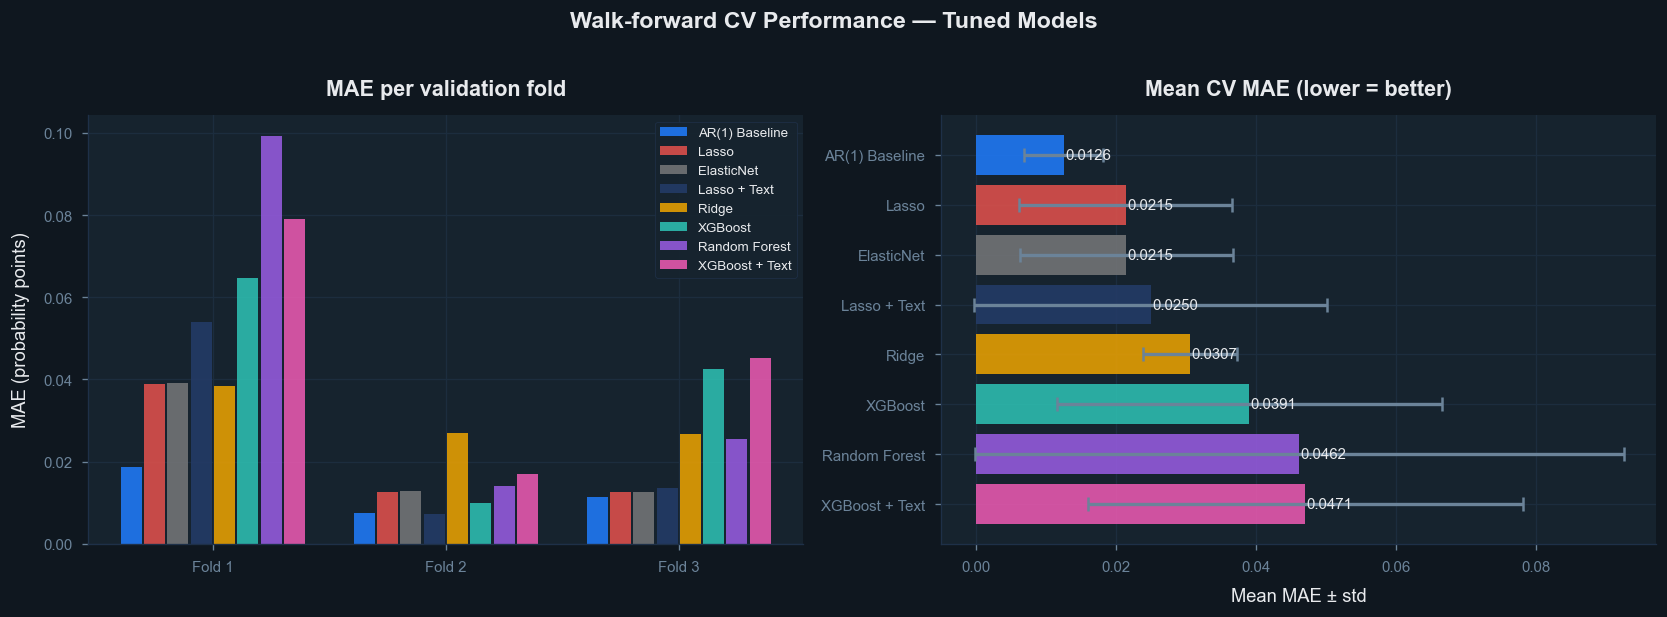

In [9]:
model_names = list(summary.index)
n_models    = len(model_names)
colors      = PALETTE[:n_models]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Walk-forward CV Performance — Tuned Models',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.02)

# Left: MAE per fold
ax = axes[0]
ax.set_facecolor(BG_PANEL)
x     = np.arange(N_SPLITS)
width = 0.8 / n_models
for i, (name, color) in enumerate(zip(model_names, colors)):
    fold_mae = cv_df[cv_df['Model'] == name].sort_values('Fold')['MAE'].values
    ax.bar(x + i * width - 0.4 + width/2, fold_mae,
           width=width * 0.9, color=color, label=name, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)], color=TEXT_MUTED)
style_ax(ax, ylabel='MAE (probability points)', title='MAE per validation fold')
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

# Right: mean ± std
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
mean_mae = [summary.loc[m, 'MAE_mean'] for m in model_names]
std_mae  = [summary.loc[m, 'MAE_std']  for m in model_names]
bars = ax2.barh(model_names, mean_mae, xerr=std_mae, color=colors,
                alpha=0.85, capsize=4,
                error_kw={'ecolor': TEXT_MUTED, 'capthick': 1.5})
for bar, val in zip(bars, mean_mae):
    ax2.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=TEXT_PRIMARY, fontsize=9)
ax2.invert_yaxis()
ax2.tick_params(colors=TEXT_MUTED)
style_ax(ax2, xlabel='Mean MAE ± std', title='Mean CV MAE (lower = better)')

plt.tight_layout()
plt.show()

## 9. Predictions vs Actual — Best Model

The best model by CV MAE is retrained on each fold's training set and
its predictions are plotted against the actual Polymarket prices.
The final panel shows the held-out test set (never seen during tuning).

Best model: AR(1) Baseline  (CV MAE = 0.01258)


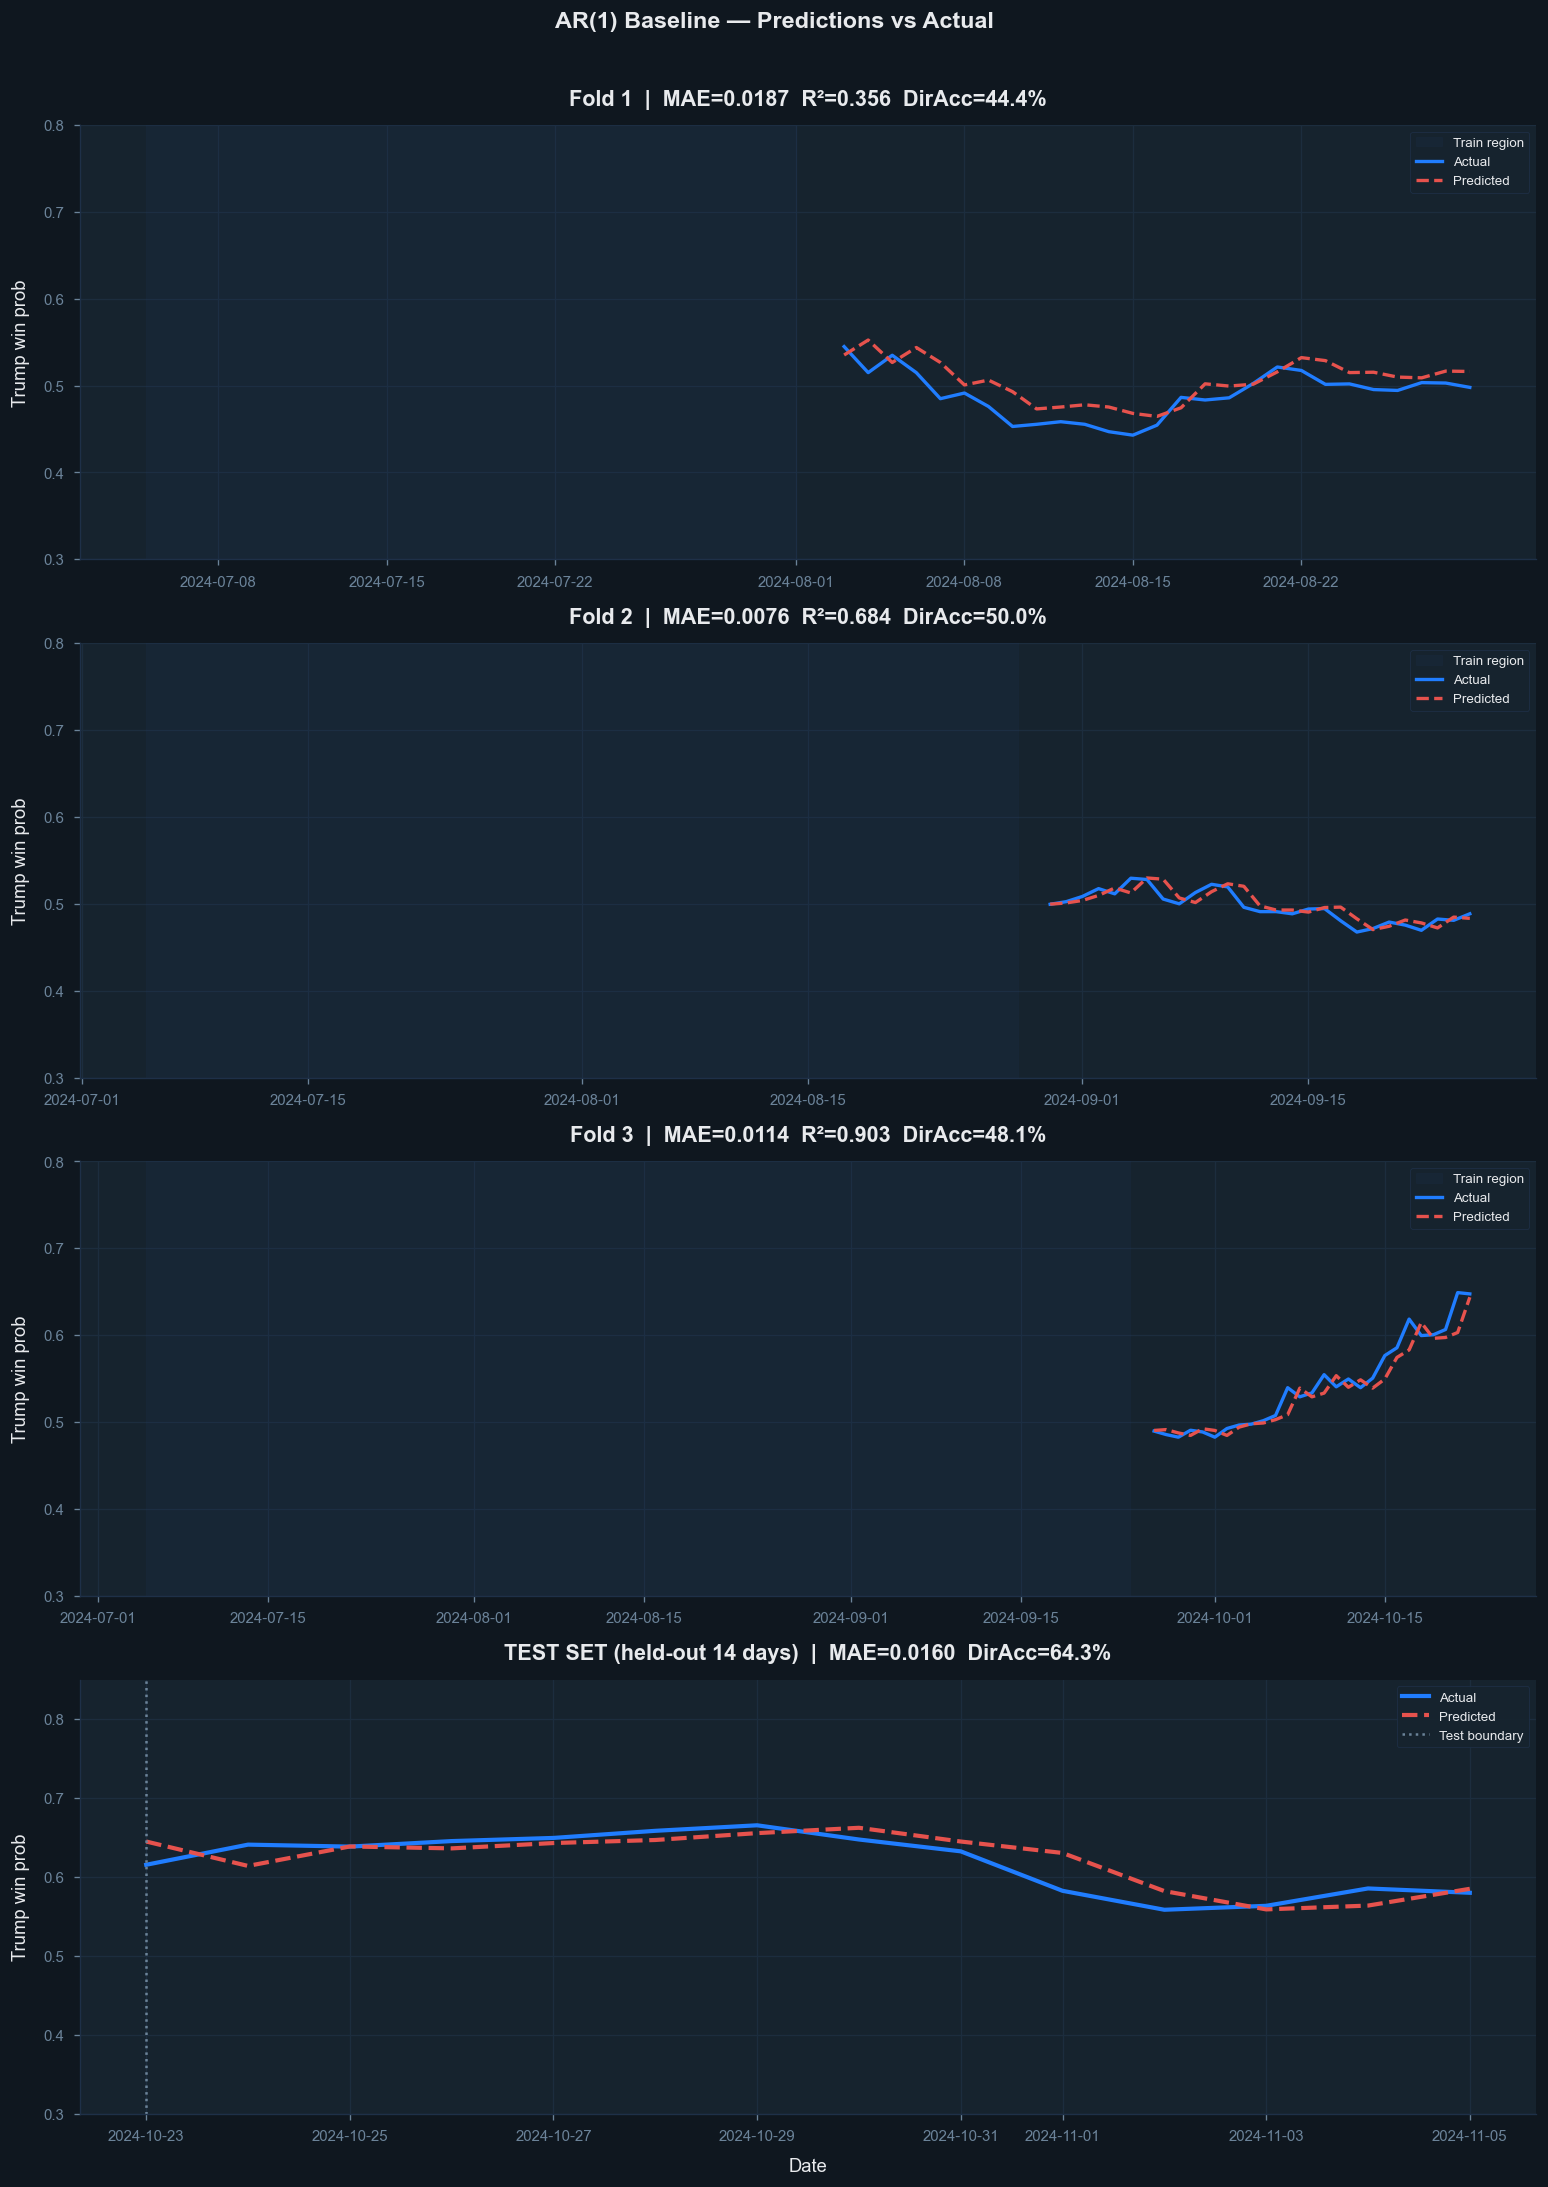

In [10]:
best_name = summary['MAE_mean'].idxmin()
best_pipe, best_feats, _use_text = TUNED_MODELS[best_name]
print(f"Best model: {best_name}  (CV MAE = {summary.loc[best_name,'MAE_mean']:.5f})")

fig, axes = plt.subplots(N_SPLITS + 1, 1, figsize=(13, 4.5 * (N_SPLITS + 1)))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(f'{best_name} — Predictions vs Actual',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.01)

for fold_i, (train_idx, val_idx) in enumerate(folds):
    ax = axes[fold_i]
    ax.set_facecolor(BG_PANEL)
    m = eval_pipeline(best_pipe, best_feats, train_idx, val_idx)
    ax.fill_betweenx([0.2, 0.9],
                     df['date'].iloc[train_idx[0]], df['date'].iloc[train_idx[-1]],
                     color=ACCENT, alpha=0.12, label='Train region')
    ax.plot(m['dates'], m['y_true'], color=DEMOCRAT,   lw=2,   label='Actual')
    ax.plot(m['dates'], m['y_pred'], color=REPUBLICAN, lw=2, ls='--', label='Predicted')
    style_ax(ax, ylabel='Trump win prob',
             title=f'Fold {fold_i+1}  |  MAE={m["MAE"]:.4f}  R²={m["R2"]:.3f}  DirAcc={m["DirAcc"]:.1%}')
    ax.set_ylim(0.3, 0.8)
    ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

# Test set panel
ax = axes[N_SPLITS]
ax.set_facecolor(BG_PANEL)
pipe_final = clone(best_pipe)
pipe_final.fit(df[best_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
y_test_pred = pipe_final.predict(df[best_feats].iloc[test_idx])
y_test_true = df[TARGET].iloc[test_idx].values
dates_test  = df['date'].iloc[test_idx].values

ax.plot(dates_test, y_test_true,  color=DEMOCRAT,   lw=2.5, label='Actual')
ax.plot(dates_test, y_test_pred,  color=REPUBLICAN, lw=2.5, ls='--', label='Predicted')
ax.axvline(dates_test[0], color=TEXT_MUTED, ls=':', lw=1.5, label='Test boundary')
mae_t = mean_absolute_error(y_test_true, y_test_pred)
da_t  = directional_accuracy(y_test_true, y_test_pred,
                              df['polymarket_trump_prob_lag1'].iloc[test_idx].values)
style_ax(ax, xlabel='Date', ylabel='Trump win prob',
         title=f'TEST SET (held-out 14 days)  |  MAE={mae_t:.4f}  DirAcc={da_t:.1%}')
ax.set_ylim(0.3, 0.85)
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

## 10. Feature Importance

**Lasso coefficients:** features with non-zero coefficients are those the model
selected as informative. Positive = increases Trump win probability, negative = decreases.

**Random Forest importances:** based on mean decrease in impurity across all trees.
Note: RF importances can be inflated for continuous or high-cardinality features.

Both models are fitted on the full train/val set (all data except the test set)
using the tuned hyperparameters.

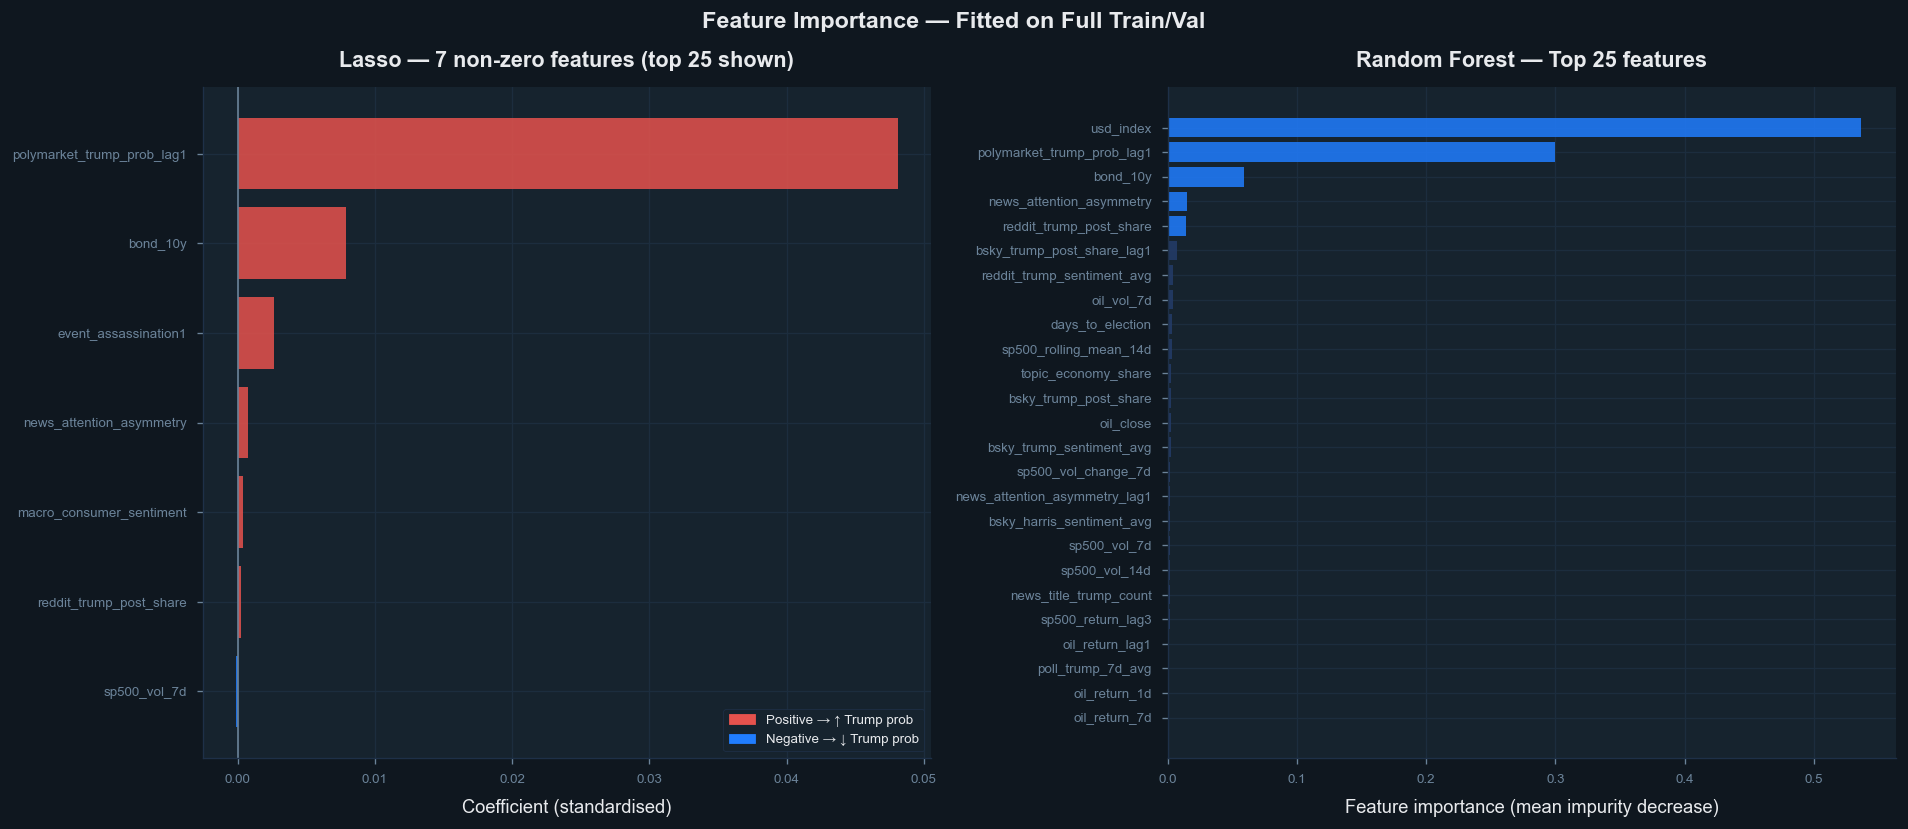

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Feature Importance — Fitted on Full Train/Val',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

# ── Lasso ──────────────────────────────────────────────────────────────────────
lasso_pipe, lasso_feats, _ = TUNED_MODELS['Lasso']
lp = clone(lasso_pipe)
lp.fit(df[lasso_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
coef = lp.named_steps['model'].coef_

coef_df = (pd.DataFrame({'feature': lasso_feats, 'coef': coef})
           .query('coef != 0').assign(abs_coef=lambda x: x['coef'].abs())
           .sort_values('abs_coef', ascending=False).head(25))

ax = axes[0]
ax.set_facecolor(BG_PANEL)
bar_colors = [REPUBLICAN if c > 0 else DEMOCRAT for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=bar_colors, alpha=0.85)
ax.axvline(0, color=TEXT_MUTED, lw=1)
ax.tick_params(colors=TEXT_MUTED, labelsize=8)
n_nonzero = (coef != 0).sum()
style_ax(ax, xlabel='Coefficient (standardised)',
         title=f'Lasso — {n_nonzero} non-zero features (top 25 shown)')
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color=REPUBLICAN, label='Positive → ↑ Trump prob'),
    mpatches.Patch(color=DEMOCRAT,   label='Negative → ↓ Trump prob'),
], facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_pipe, rf_feats, _ = TUNED_MODELS['Random Forest']
rfp = clone(rf_pipe)
rfp.fit(df[rf_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
importances = rfp.named_steps['model'].feature_importances_

fi_df = (pd.DataFrame({'feature': rf_feats, 'importance': importances})
         .sort_values('importance', ascending=False).head(25))

ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
bar_clr = [PALETTE[0] if i < 5 else PALETTE[3] for i in range(len(fi_df))]
ax2.barh(fi_df['feature'], fi_df['importance'], color=bar_clr, alpha=0.85)
ax2.tick_params(colors=TEXT_MUTED, labelsize=8)
style_ax(ax2, xlabel='Feature importance (mean impurity decrease)',
         title='Random Forest — Top 25 features')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Final Test Set Evaluation

The held-out test set (final 14 days) is now used for the **first and only time**.
Each tuned model is retrained on the complete train/val data before predicting.

This gives an unbiased estimate of real-world performance — the model has never
seen these dates during training or hyperparameter selection.

Model                       MAE     RMSE       R²    DirAcc
------------------------------------------------------------
AR(1) Baseline           0.0160   0.0202    0.682    64.3%
Ridge                    0.0312   0.0393   -0.206    42.9%
Lasso                    0.0175   0.0210    0.657    50.0%
ElasticNet               0.0177   0.0211    0.651    50.0%


Random Forest            0.0287   0.0323    0.186    57.1%
XGBoost                  0.0261   0.0335    0.125    57.1%


Lasso + Text             0.0199   0.0228    0.595    50.0%


XGBoost + Text           0.0343   0.0387   -0.167    50.0%


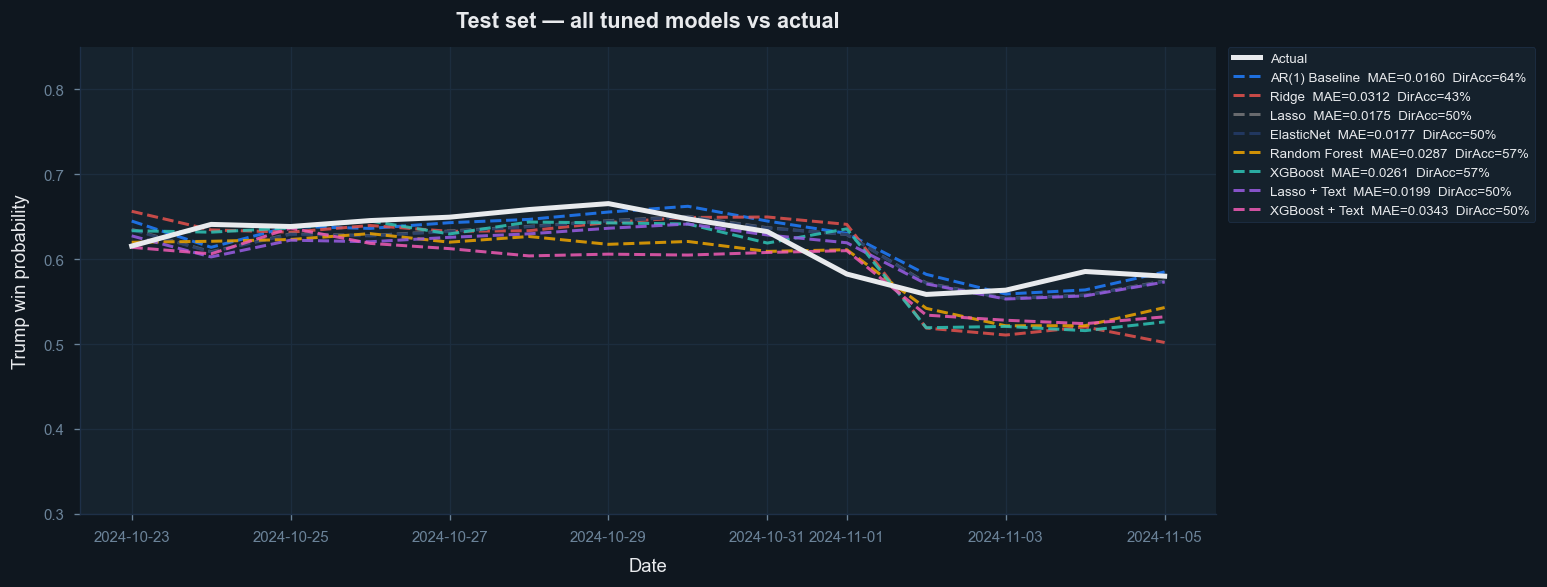

In [12]:
test_res = {}
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'DirAcc':>9}")
print("-" * 60)
for model_name, (pipeline, feat_cols, _use_text) in TUNED_MODELS.items():
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[tv_idx], df[TARGET].iloc[tv_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[test_idx])
    y_true = df[TARGET].iloc[test_idx].values
    lag_t  = df['polymarket_trump_prob_lag1'].iloc[test_idx].values
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    da   = directional_accuracy(y_true, y_pred, lag_t)
    test_res[model_name] = {'y_pred': y_pred, 'y_true': y_true,
                             'MAE': mae, 'RMSE': rmse, 'R2': r2, 'DirAcc': da}
    print(f"{model_name:<22} {mae:>8.4f} {rmse:>8.4f} {r2:>8.3f} {da:>8.1%}")

# ── All predictions on test set ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

dates_test = df['date'].iloc[test_idx].values
first_model = list(test_res.keys())[0]
ax.plot(dates_test, test_res[first_model]['y_true'],
        color=TEXT_PRIMARY, lw=3, label='Actual', zorder=5)

for (name, res), color in zip(test_res.items(), PALETTE):
    ax.plot(dates_test, res['y_pred'], color=color, lw=1.8, ls='--', alpha=0.85,
            label=f"{name}  MAE={res['MAE']:.4f}  DirAcc={res['DirAcc']:.0%}")

style_ax(ax, xlabel='Date', ylabel='Trump win probability',
         title='Test set — all tuned models vs actual')
ax.set_ylim(0.3, 0.85)
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()